# Possession vs Winning

## Germany vs Japan - FIFA World Cup 2022 Analysis

This project investigates whether having more possession and completing more passes always leads to winning a football match.

The case study is Germany vs Japan in the FIFA World Cup 2022, where Germany dominated possession and passing statistics but lost the match 2-1.

Data Source:
FIFA World Cup 2022 Official Match Report and MLPSOCCER

## Research Question

Does higher possession and passing accuracy guarantee a higher probability of winning?

To answer this question, I analyze:

- Possession
- Passing volume
- Passing accuracy
- Shot quality
- Expected Goals (xG)
- Offensive efficiency

In [18]:
# STEP 1 # Install the required libraries for soccer analytics
!pip install statsbombpy mplsoccer pandas matplotlib seaborn

In [19]:
# STEP 2 # Extracting the Match Data

from statsbombpy import sb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch
import warnings
warnings.filterwarnings('ignore')

# Fetch all matches from the 2022 World Cup (Competition 43, Season 106)
matches = sb.matches(competition_id=43, season_id=106)

# Locate the Germany vs Japan match dynamically
match_df = matches[(matches['home_team'] == 'Germany') & (matches['away_team'] == 'Japan')]
match_id = match_df.match_id.values[0]

print(f"Extracting data for Match ID: {match_id}")

# Fetch all events (passes, shots, tackles, etc.) for this specific match
events = sb.events(match_id=match_id)

Extracting data for Match ID: 3857284


In [20]:
# STEP 3 # Analyzing "The Illusion" (Basic Metrics)

# Filter for passing events
passes = events[events['type'] == 'Pass']

# Count total passes per team
pass_counts = passes.groupby('team').size()
print("Total Passes Attempted:")
print(pass_counts)

# Calculate simple possession based on pass volume
total_match_passes = pass_counts.sum()
possession = (pass_counts / total_match_passes) * 100
print("\nPossession % (Based on Pass Volume):")
print(possession.round(2))

Total Passes Attempted:
team
Germany    826
Japan      294
dtype: int64

Possession % (Based on Pass Volume):
team
Germany    73.75
Japan      26.25
dtype: float64


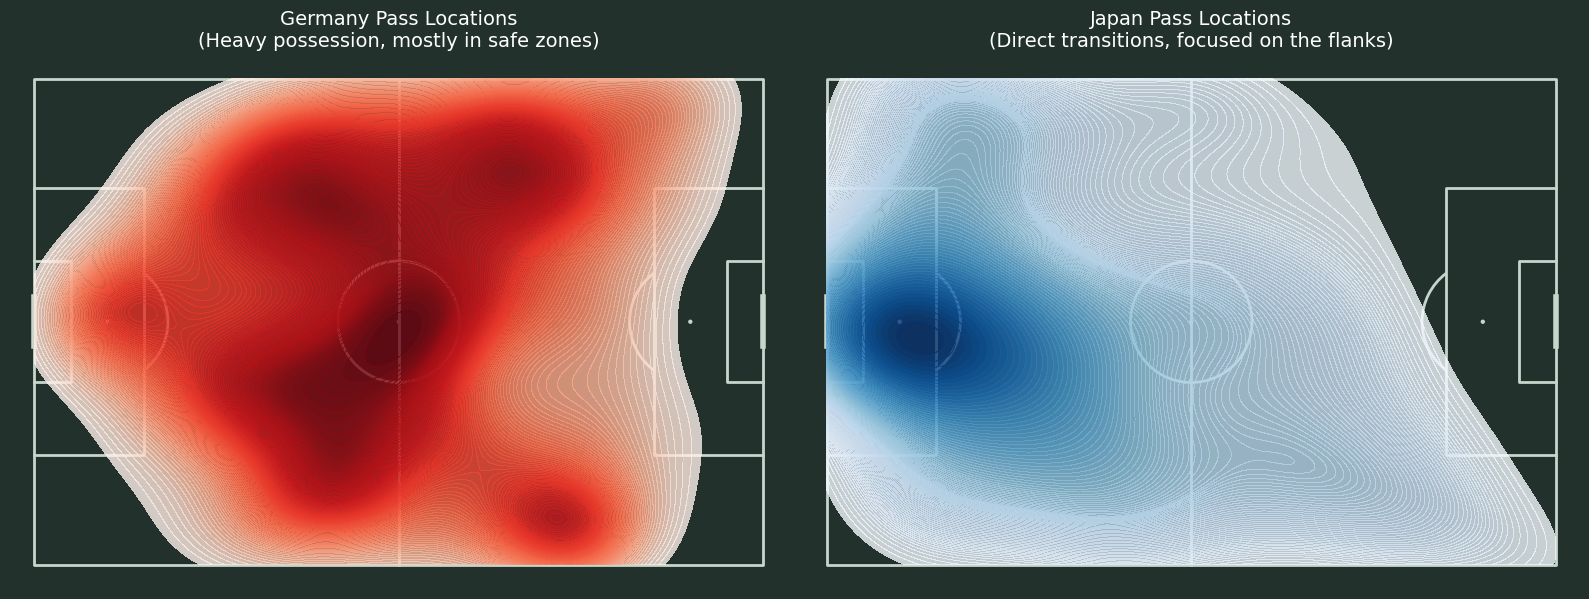

In [21]:
# STEP 4 # Where Did Possession Happen? (Heatmaps)

# Extract X and Y coordinates for passes
# StatsBomb locations are stored in a list [x, y]
passes[['x', 'y']] = pd.DataFrame(passes.location.tolist(), index=passes.index)

# Separate data by team
ger_passes = passes[passes['team'] == 'Germany']
jpn_passes = passes[passes['team'] == 'Japan']

# Setup the pitch using mplsoccer
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(16, 8), ncols=2)

# Plot Germany Heatmap
pitch.kdeplot(ger_passes.x, ger_passes.y, ax=ax[0], cmap='Reds', fill=True, levels=100, alpha=0.8)
ax[0].set_title('Germany Pass Locations\n(Heavy possession, mostly in safe zones)', color='white', fontsize=14)

# Plot Japan Heatmap
pitch.kdeplot(jpn_passes.x, jpn_passes.y, ax=ax[1], cmap='Blues', fill=True, levels=100, alpha=0.8)
ax[1].set_title('Japan Pass Locations\n(Direct transitions, focused on the flanks)', color='white', fontsize=14)

fig.set_facecolor('#22312b')
plt.show()

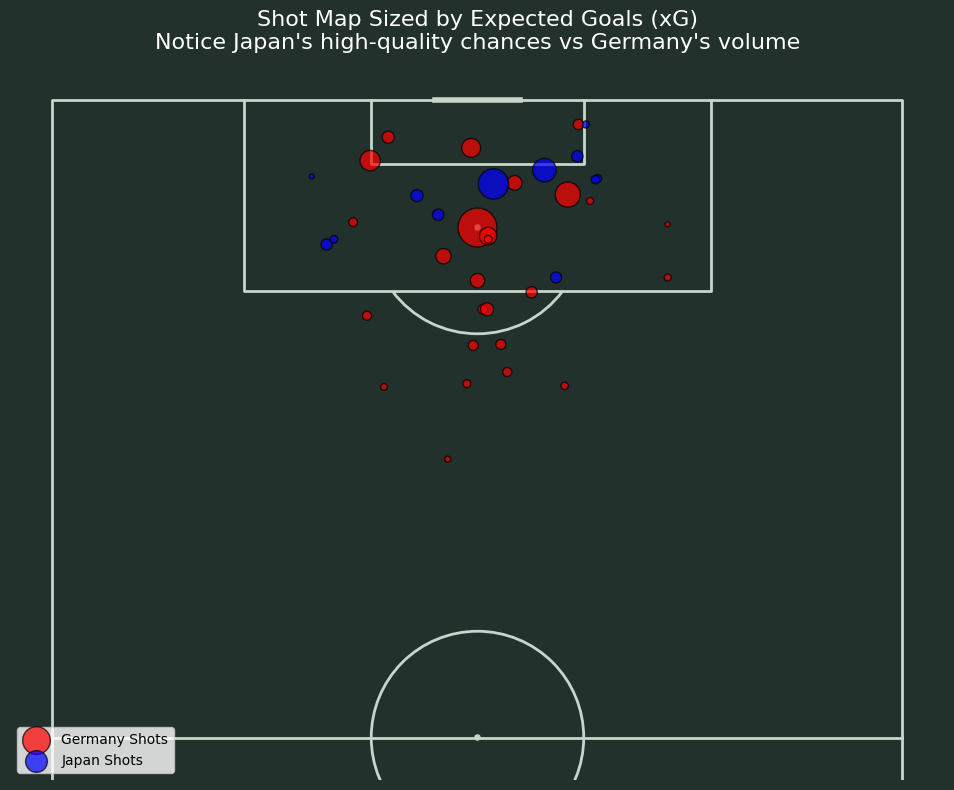

In [22]:
# STEP 5 # Quality over Quantity (Expected Goals - xG)

# Filter for shots
shots = events[events['type'] == 'Shot'].copy()

# Safely extract X and Y coordinates (ignoring Z-axis if present)
shots['x'] = shots['location'].apply(lambda loc: loc[0] if isinstance(loc, list) and len(loc) > 0 else None)
shots['y'] = shots['location'].apply(lambda loc: loc[1] if isinstance(loc, list) and len(loc) > 1 else None)

# Safely extract xG handling statsbombpy's flattened columns
if 'shot_statsbomb_xg' in shots.columns:
    shots['xg'] = shots['shot_statsbomb_xg']
elif 'shot' in shots.columns:
    # Fallback if the dictionary wasn't flattened
    shots['xg'] = shots['shot'].apply(lambda x: x.get('statsbomb_xg') if isinstance(x, dict) else 0.0)
else:
    print("Warning: xG data not found in expected columns. Defaulting to 0.")
    shots['xg'] = 0.0

# Clean up any potential NaN values in xG
shots['xg'] = shots['xg'].fillna(0.0)

# Separate teams
ger_shots = shots[shots['team'] == 'Germany']
jpn_shots = shots[shots['team'] == 'Japan']

# Setup the vertical half-pitch
pitch = VerticalPitch(pitch_type='statsbomb', half=True, pitch_color='#22312b', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(12, 8))

# Plot Germany shots (Red)
# Note: We multiply xg by 1000 (or adjust as needed) to make the scatter bubble sizes visible
pitch.scatter(ger_shots.x, ger_shots.y, s=ger_shots['xg']*1000,
              edgecolors='black', c='red', ax=ax, alpha=0.7, label='Germany Shots')

# Plot Japan shots (Blue)
pitch.scatter(jpn_shots.x, jpn_shots.y, s=jpn_shots['xg']*1000,
              edgecolors='black', c='blue', ax=ax, alpha=0.7, label='Japan Shots')

# Title and formatting
ax.set_title('Shot Map Sized by Expected Goals (xG)\nNotice Japan\'s high-quality chances vs Germany\'s volume',
             color='white', fontsize=16)

ax.legend(loc='lower left')
fig.set_facecolor('#22312b')
plt.show()

### Conclusion: The Illusion of Control

By analyzing the data and visualizations above, we can draw a clear conclusion about why high possession does not always guarantee a victory. This match perfectly illustrates the concept of "sterile possession" versus "clinical transition."

**1. The Heatmaps: Where the Game Was Played**
*   **Germany (The "U-Shape" Possession):** While Germany overwhelmingly dominated the ball, the heatmap reveals that their passes were heavily concentrated in the middle of the pitch and just outside the penalty area. They circulated the ball from side to side without penetrating the most dangerous zones. Their possession was largely "sterile," acting almost as a defensive mechanism rather than an attacking threat.
*   **Japan (Direct Transitions):** Japan's heatmap reflects a deep, disciplined defensive block combined with sharp, direct movements on the flanks. When they won the ball, they didn't waste time with lateral passes; they immediately launched fast, vertical transitions toward the opponent's goal.

**2. The Shot Map & xG: Quantity vs. Quality**
*   **Germany (High Volume, Low Quality):** The shot map displays numerous red circles for Germany, but most of them are small. This indicates that despite taking many shots, they were repeatedly forced into low-probability attempts (low Expected Goals - xG) against a well-organized defense.
*   **Japan (Low Volume, High Quality):** Japan has far fewer blue circles, but crucially, the ones inside the box are significantly larger. Despite having only a fraction of the possession, Japan generated high-quality, clear-cut chances when it mattered most, ultimately converting them into goals.

**Final Thought**
In modern football analytics, having 70% possession can sometimes be an illusion of control. If a team fails to convert ball dominance into high-quality chances (xG), they remain highly vulnerable to opponents who prioritize spatial efficiency and rapid transitions. Japan's victory was not a stroke of luck, but a masterclass in exploiting sterile possession.